---
# Setup

In [8]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import importlib
import utils
importlib.reload(utils)
from utils import *

from scipy.stats import beta as beta_dist
import ipywidgets as widgets
from IPython.display import display


In [2]:
#@title Figure settings
import ipywidgets as widgets       # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/NMA2020/nma.mplstyle")

---

# Tutorial Objectives
  
* In this tutorial, we will implement Environment and Agent class for N-arm bandit task
* You will understand a Bayesian method to update the expected reward and its distribution using "Thompson sampling".
* Content creator: Sunghsin Kim

---
## Setup

## Making simple bandit environments

#### Beta distribution

In [3]:

# Set up the widgets
alpha_slider = widgets.FloatSlider(
    value=2.0,
    min=0.1,
    max=10.0,
    step=0.1,
    description='Alpha:',
    readout_format='.1f'
)

beta_slider = widgets.FloatSlider(
    value=2.0,
    min=0.1,
    max=10.0,
    step=0.1,
    description='Beta:',
    readout_format='.1f'
)

x_slider = widgets.FloatSlider(
    value=0.5,
    min=0,
    max=1,
    step=0.01,
    description='X:',
    readout_format='.2f'
)

# Define the update function
def update(alpha, beta, x):
    # Calculate the probability that the random variable of the beta distribution is larger than x
    prob = 1 - beta_dist.cdf(x, alpha, beta)
    
    # Clear the previous plot
    plt.clf()
    
    # Plot the beta distribution
    fig, ax = plt.subplots(figsize=(8,6))
    x_vals = np.linspace(0, 1, 100)
    y_vals = beta_dist.pdf(x_vals, alpha, beta)
    ax.plot(x_vals, y_vals, linewidth=2)
    ax.set_xlabel('X')
    ax.set_ylabel('Density')
    ax.set_title('Beta Distribution (α={}, β={})\nP(X > {}) = {:.4f}'.format(alpha, beta, x, prob))
    
    # Plot the shaded area for P(X > x)
    ax.fill_between(x_vals, y_vals, where=x_vals >= x, color='gray', alpha=0.5)
    
    plt.show()

# Set up the button and output widgets
button = widgets.Button(description='Update Plot')
output = widgets.Output()

# Define the button callback function
def on_button_clicked(button):
    with output:
        output.clear_output()
        update(alpha_slider.value, beta_slider.value, x_slider.value)

# Attach the button callback function to the button
button.on_click(on_button_clicked)

# Display the widgets and the output
display(alpha_slider, beta_slider, x_slider, button, output)



NameError: name 'widgets' is not defined

In [9]:
class KBandit:
    def __init__(self, n_arms, reward_type='binary', stationary=True):
        self.n_arms = n_arms
        self.reward_type = reward_type
        self.stationary = stationary
        if self.reward_type == "continuous":
            self.action_values = np.random.normal(size=self.n_arms)
            self.reward_func = self._continuous_reward
        elif self.reward_type == "binary":
            self.action_values = np.random.rand(self.n_arms)
            self.reward_func = self._binary_reward
        else:
            raise ValueError("Reward type not recognized")
    
    def _continuous_reward(self, action):
        # Return a normally distributed reward with mean equal to the true action value
        return np.random.normal(self.action_values[action])
    
    def _binary_reward(self, action):
        # Return a binary reward with probability equal to the reward_probs for that action
        return np.random.choice([0, 1], p=[1-self.action_values[action], self.action_values[action]])
    
    def step(self, action):
        # Take an action and return the corresponding reward
        reward = self.reward_func(action)
        self.optimal = np.argmax(self.action_values)
        if not self.stationary:
            # Update action values and reward probabilities using random walks
            self.action_values += np.random.normal(0, 0.03, self.n_arms)
            if self.reward_type=='binary':
                self.action_values = np.clip(self.action_values, 0, 1)


        return reward, action==self.optimal


In [10]:
class RandomAgent():
    def __init__(self, k):
        self.num_actions = k
        # you could add parameters to your agent here
        pass
    
    def choose(self):
        return np.random.randint(self.num_actions)
    def update(self, action, reward): # this agent doesn't learn
        pass

In [11]:
class BernoulliThompsonAgent:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.alpha = np.ones(n_arms)
        self.beta = np.ones(n_arms)
        self.timestep = 0
        
    def choose(self):
        samples = np.random.beta(self.alpha, self.beta)
        action = np.argmax(samples)
        return action
    
    def update(self, action, reward):
        self.timestep += 1
        self.alpha[action] += reward
        self.beta[action] += 1 - reward
    def reset(self):
        self.alpha = np.ones(n_arms)
        self.beta = np.ones(n_arms)
        self.timestep = 0
        

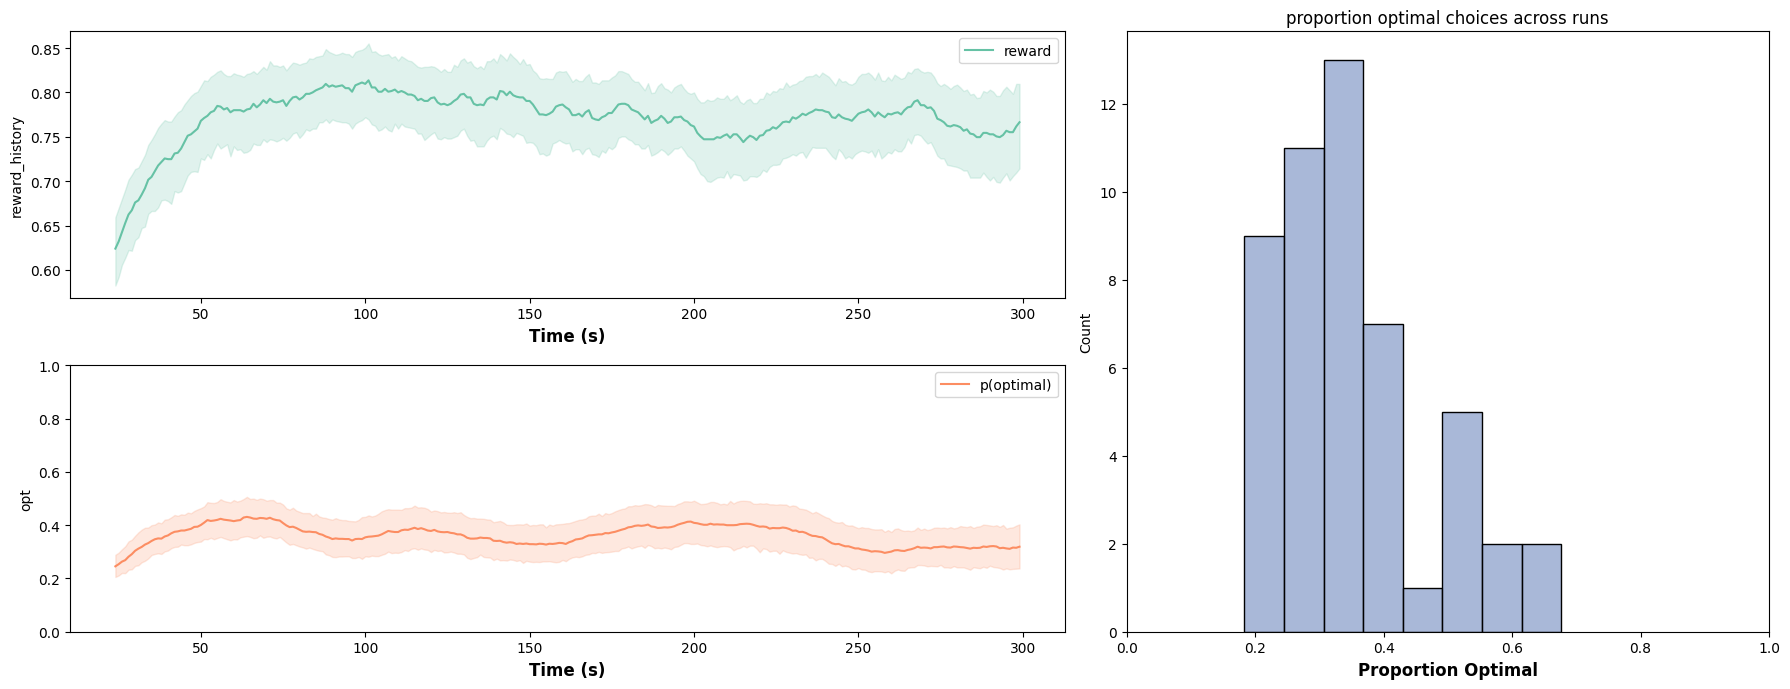

In [12]:
np.random.seed(100) # fix a seed for repeatable experiments

# parameters of simulation
n_timesteps = 300
n_runs = 50

# set up bandit options
n_bandits = 10
# bandit_means = [0,50,10,4]
# bandit_sds = [1]*n_bandits

reward_history = []
opt_history = []
run_history = []
timestep = []
for run in range(n_runs):  # repeat a given number random repetitions of the experiment
    action_means = []
    bandit = KBandit(n_bandits, stationary=False) # create a new bandit
    #agent = RandomAgent(n_bandits)
    agent = BernoulliThompsonAgent(n_bandits)
  #  np.random.shuffle(bandit_means) # randomize location of "best"
    for i in range(n_timesteps): # for a certain number of time steps
        action = agent.choose() # let the agent choose
        reward, opt = bandit.step(action)
        agent.update(action, reward)
        reward_history.append(reward)
        opt_history.append(opt)
        run_history.append(run)
        timestep.append(i)
        action_means.append(bandit.action_values)
# plot the results
sim_result_df=pd.DataFrame({"run": run_history, "timepoint": timestep, "reward_history":reward_history, "opt": opt_history})
plot_results(sim_result_df)

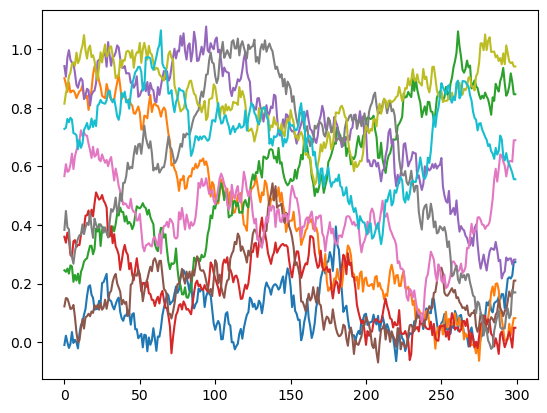

In [11]:
plt.plot(np.array(action_means))
plt.show()